# 05d — Anger × Delegitimisation rate per topic

Scatter plot: x = mean anger score, y = delegitimisation rate.  
Each dot = one **Manual Topic Label**; coloured by **Manual Cluster Label**.  
Data: `emotion_mainstream_resultsv3.csv` merged with topic assignments.

In [56]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

ROOT = Path("/Users/gretawette/Documents/Thesis")

df = pd.read_csv(ROOT / "04_SentimentAnalysis/outputs/emotion_mainstream_resultsv3.csv")
df.columns = df.columns.str.strip()

topics = pd.read_csv(ROOT / "02_TopicModeling/outputs/03_new_topic_assignments.csv")
topics["Manual Cluster Label"] = topics["Manual Cluster Label"].str.rstrip("#").str.strip()
topics["source"] = topics["source"].replace({"RT": "RT_de", "Tichys Einblick": "Tichys_Einblick"})

df = df.merge(
    topics[["row_id", "Manual Topic Label", "Manual Cluster Label"]].drop_duplicates("row_id"),
    on="row_id", how="left"
)

# Drop IRRELEVANT; keep NEUTRAL and framing rows
df = df[df["category"] != "IRRELEVANT"].copy()
df["emotion_anger"] = pd.to_numeric(df["emotion_anger"], errors="coerce")
print(f"Rows: {len(df):,}  |  Topics assigned: {df['Manual Topic Label'].notna().sum():,}")


Rows: 11,666  |  Topics assigned: 11,288


In [57]:
# ── Per-topic aggregation ─────────────────────────────────────────────────────
MIN_N = 10   # minimum hits per topic to include

df_t = df.dropna(subset=["Manual Topic Label"]).copy()

agg = df_t.groupby(["Manual Topic Label", "Manual Cluster Label"]).agg(
    anger   = ("emotion_anger", "mean"),
    n_total = ("category",      "count"),
    n_frame = ("category",      lambda x: (x != "NEUTRAL").sum()),
).reset_index()

agg["deleg_rate"] = agg["n_frame"] / agg["n_total"] * 100
agg = agg[agg["n_total"] >= MIN_N].copy()
print(f"Topics kept (n >= {MIN_N}): {len(agg)}")
agg.sort_values("deleg_rate", ascending=False).head(10)


Topics kept (n >= 10): 72


,Manual Topic Label,Manual Cluster Label,anger,n_total,n_frame,deleg_rate
21,Corruption Journalism,Media & Information Ecosystem,0.833947,312,222,71.153846
13,Charlie Kirk Incident,US & Transatlantic Politics,0.850181,197,131,66.497462
46,Journalism Broadcasters,Media & Information Ecosystem,0.804951,118,78,66.101695
55,Radio Format Metadata,Miscellaneous,0.767577,62,38,61.290323
51,NYC Mayoral Election,US & Transatlantic Politics,0.794916,20,11,55.000000
15,Christianity Religion,Miscellaneous,0.790223,97,52,53.608247
71,Wolfram Weimer Media,Media & Information Ecosystem,0.814956,345,179,51.884058
10,Books and Authors,Miscellaneous,0.780629,154,77,50.000000
35,"German TV, Talk Shows & ÖRR Criticism",Media & Information Ecosystem,0.872627,269,133,49.442379
37,Green Politics & Woke Culture#,Identity & Culture War,0.838874,112,54,48.214286


In [58]:
# # ── Scatter plot: anger score × delegitimisation rate per topic ───────────────
# clusters = sorted(agg["Manual Cluster Label"].dropna().unique())
# cmap     = plt.cm.get_cmap("tab20", len(clusters))
# c_color  = {cl: cmap(i) for i, cl in enumerate(clusters)}

# fig, ax = plt.subplots(figsize=(11, 8))

# for _, row in agg.iterrows():
#     color = c_color.get(row["Manual Cluster Label"], "#aaaaaa")
#     ax.scatter(row["anger"], row["deleg_rate"],
#                color=color, s=max(30, row["n_total"] * 0.3),
#                alpha=0.75, edgecolors="white", linewidths=0.4, zorder=3)
#     # Label only topics with high framing or high anger
#     if row["deleg_rate"] > 40 or row["anger"] > agg["anger"].quantile(0.9):
#         ax.annotate(
#             row["Manual Topic Label"],
#             xy=(row["anger"], row["deleg_rate"]),
#             xytext=(4, 4), textcoords="offset points",
#             fontsize=6.5, color="#333333",
#         )

# # Macro-mean reference lines
# ax.axhline(agg["deleg_rate"].mean(), color="#aaaaaa", linewidth=0.8,
#            linestyle="--", label=f"Mean deleg. rate ({agg['deleg_rate'].mean():.1f}%)")
# ax.axvline(agg["anger"].mean(), color="#aaaaaa", linewidth=0.8,
#            linestyle=":", label=f"Mean anger ({agg['anger'].mean():.3f})")

# ax.set_xlabel("Mean anger score (sigmoid, per topic)", fontsize=11)
# ax.set_ylabel("Delegitimisation rate  (% non-neutral hits)", fontsize=11)
# ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0f}%"))
# ax.set_title(
#     "Anger score × delegitimisation rate per topic\n"
#     "(dot size ∝ n hits; coloured by cluster · IRRELEVANT excluded)",
#     fontsize=12, fontweight="bold",
# )
# ax.spines[["top", "right"]].set_visible(False)
# ax.grid(True, linestyle="--", alpha=0.3)
# ax.set_axisbelow(True)

# # Cluster legend
# from matplotlib.lines import Line2D
# handles = [Line2D([0],[0], marker="o", color="w", markerfacecolor=c_color[cl],
#                   markersize=8, label=cl) for cl in clusters if cl in c_color]
# ax.legend(handles=handles, title="Cluster", fontsize=7, title_fontsize=8,
#           loc="upper left", bbox_to_anchor=(1.01, 1), frameon=True)

# plt.tight_layout()
# plt.savefig(ROOT / "04_SentimentAnalysis/outputs/figures/05d_anger_vs_deleg_per_topic.png",
#             dpi=150, bbox_inches="tight")
# plt.show()


In [59]:
df = df[df["source"] != "Tagesschau"].copy()

In [60]:
# ── Per-topic aggregation for FEAR ───────────────────────────────────────────
agg_fear = df.dropna(subset=["Manual Topic Label"]).groupby(
    ["Manual Topic Label", "Manual Cluster Label"]
).agg(
    fear    = ("emotion_fear", "mean"),
    n_total = ("category",     "count"),
    n_frame = ("category",     lambda x: (x != "NEUTRAL").sum()),
).reset_index()

agg_fear["emotion_fear"] = pd.to_numeric(agg_fear["fear"], errors="coerce")
agg_fear["deleg_rate"]   = agg_fear["n_frame"] / agg_fear["n_total"] * 100
agg_fear = agg_fear[agg_fear["n_total"] >= MIN_N].copy()
print(f"Topics kept (n >= {MIN_N}): {len(agg_fear)}")


Topics kept (n >= 10): 66


In [61]:
from scipy.stats import pearsonr, spearmanr

for label, scores, deleg in [
    ("Anger",  agg["anger"],            agg["deleg_rate"]),
    ("Fear",   agg_fear["emotion_fear"], agg_fear["deleg_rate"]),
]:
    r_p, p_p = pearsonr(scores.dropna(),  deleg[scores.notna()])
    r_s, p_s = spearmanr(scores.dropna(), deleg[scores.notna()])
    print(f"{label}:")
    print(f"  Pearson  r = {r_p:.3f},  p = {p_p:.4f}")
    print(f"  Spearman ρ = {r_s:.3f},  p = {p_s:.4f}")
    print()

Anger:
  Pearson  r = 0.840,  p = 0.0000
  Spearman ρ = 0.853,  p = 0.0000

Fear:
  Pearson  r = -0.075,  p = 0.5491
  Spearman ρ = -0.152,  p = 0.2227



## Cluster-level view

Same scatter logic, but aggregated to **Manual Cluster Label** (one dot = one cluster).

In [62]:
# ── Per-cluster aggregation ──────────────────────────────────────────────────
MIN_N_CLUSTER = 30  # minimum hits per cluster to include

df["emotion_fear"] = pd.to_numeric(df["emotion_fear"], errors="coerce")

agg_cluster = (
    df.dropna(subset=["Manual Cluster Label"])
      .groupby("Manual Cluster Label")
      .agg(
          anger   = ("emotion_anger", "mean"),
          fear    = ("emotion_fear",  "mean"),
          n_total = ("category",      "count"),
          n_frame = ("category",      lambda x: (x != "NEUTRAL").sum()),
      )
      .reset_index()
)

agg_cluster["deleg_rate"] = agg_cluster["n_frame"] / agg_cluster["n_total"] * 100
agg_cluster = agg_cluster[agg_cluster["n_total"] >= MIN_N_CLUSTER].copy()
print(f"Clusters kept (n >= {MIN_N_CLUSTER}): {len(agg_cluster)}")
agg_cluster.sort_values("deleg_rate", ascending=False)

Clusters kept (n >= 30): 18


,Manual Cluster Label,anger,fear,n_total,n_frame,deleg_rate
10,Media & Information Ecosystem,0.841143,0.188771,1030,621,60.291262
7,Identity & Culture War,0.847211,0.240142,276,139,50.362319
17,US & Transatlantic Politics,0.798866,0.241536,530,256,48.301887
13,Miscellaneous,0.779375,0.211072,523,252,48.183556
2,"Free Speech, Crime & Political Repression",0.821856,0.268137,384,171,44.531250
11,Middle East,0.752571,0.251255,340,139,40.882353
9,Justice System & Political Conflict,0.765408,0.194929,278,108,38.848921
15,Russia-Ukraine War,0.755735,0.251390,335,112,33.432836
8,International Affairs,0.716699,0.224579,193,61,31.606218
0,"Energy, Climate & Environment",0.770721,0.241707,232,73,31.465517


In [63]:
# # ── Scatter plot: anger × delegitimisation rate per cluster ──────────────────
# fig, ax = plt.subplots(figsize=(11, 8))

# for _, row in agg_cluster.iterrows():
#     color = c_color.get(row["Manual Cluster Label"], "#aaaaaa")
#     ax.scatter(row["anger"], row["deleg_rate"],
#                color=color, s=max(80, row["n_total"] * 0.05),
#                alpha=0.85, edgecolors="white", linewidths=0.6, zorder=3)
#     ax.annotate(
#         # row["Manual Cluster Label"],
#         xy=(row["anger"], row["deleg_rate"]),
#         xytext=(6, 4), textcoords="offset points",
#         fontsize=8, color="#333333",
#     )

# ax.axhline(agg_cluster["deleg_rate"].mean(), color="#aaaaaa", linewidth=0.8,
#            linestyle="--", label=f"Mean deleg. rate ({agg_cluster['deleg_rate'].mean():.1f}%)")
# ax.axvline(agg_cluster["anger"].mean(), color="#aaaaaa", linewidth=0.8,
#            linestyle=":", label=f"Mean anger ({agg_cluster['anger'].mean():.3f})")

# ax.set_xlabel("Mean anger score (sigmoid, per cluster)", fontsize=11)
# ax.set_ylabel("Delegitimisation rate  (% non-neutral hits)", fontsize=11)
# ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0f}%"))
# ax.set_title(
#     "Anger score × delegitimisation rate per cluster\n"
#     "(dot size ∝ n hits · IRRELEVANT excluded)",
#     fontsize=12, fontweight="bold",
# )
# ax.spines[["top", "right"]].set_visible(False)
# ax.grid(True, linestyle="--", alpha=0.3)
# ax.set_axisbelow(True)
# ax.legend(loc="upper left", fontsize=8)

# plt.tight_layout()
# plt.savefig(ROOT / "04_SentimentAnalysis/outputs/figures/05d_anger_vs_deleg_per_cluster.png",
#             dpi=150, bbox_inches="tight")
# plt.show()

In [64]:
# ── Cluster-level correlations ───────────────────────────────────────────────
for label, scores in [("Anger", agg_cluster["anger"]),
                      ("Fear",  agg_cluster["fear"])]:
    deleg = agg_cluster["deleg_rate"]
    mask  = scores.notna() & deleg.notna()
    r_p, p_p = pearsonr(scores[mask],  deleg[mask])
    r_s, p_s = spearmanr(scores[mask], deleg[mask])
    print(f"{label} (cluster level, n = {mask.sum()}):")
    print(f"  Pearson  r = {r_p:.3f},  p = {p_p:.4f}")
    print(f"  Spearman ρ = {r_s:.3f},  p = {p_s:.4f}")
    print()

Anger (cluster level, n = 18):
  Pearson  r = 0.825,  p = 0.0000
  Spearman ρ = 0.730,  p = 0.0006

Fear (cluster level, n = 18):
  Pearson  r = 0.120,  p = 0.6366
  Spearman ρ = 0.214,  p = 0.3947



## Combined view

Topics shown as faint grey dots in the background (no labels); clusters overlaid as coloured dots with labels.

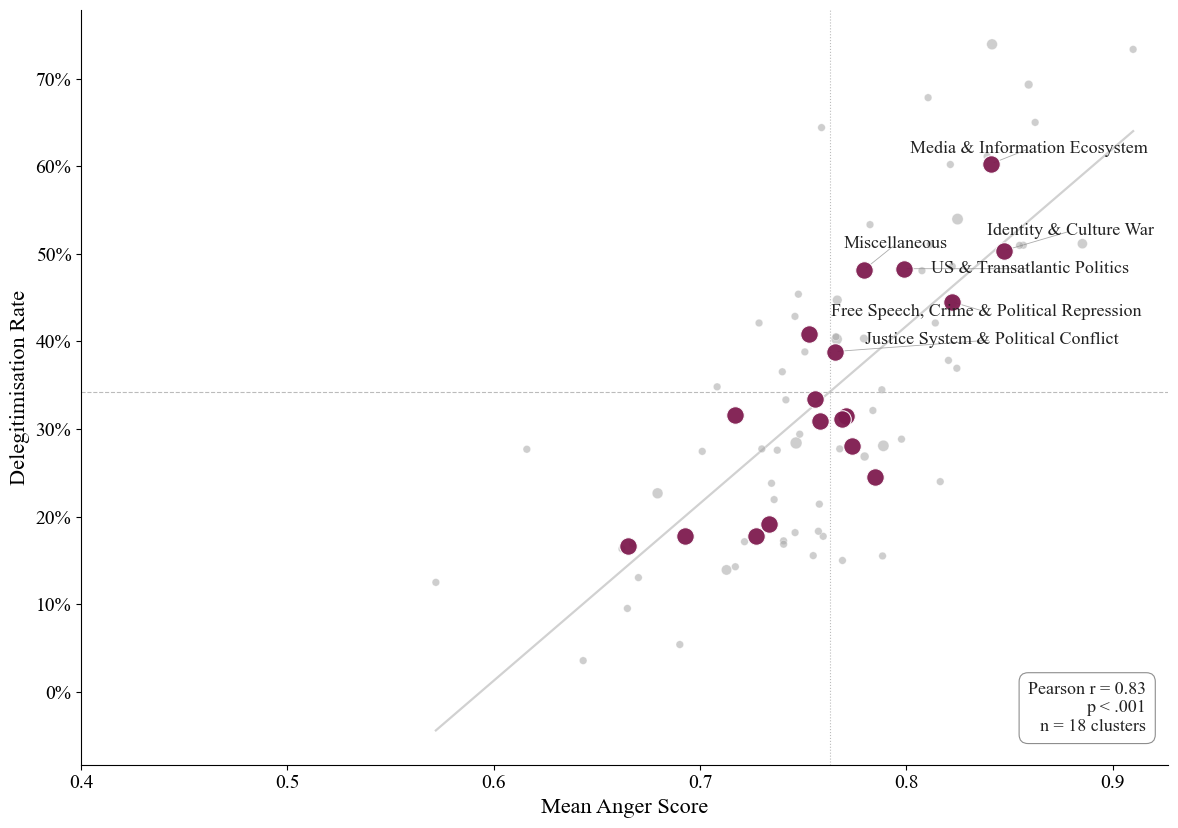

In [65]:
# ── Combined: anger × delegitimisation rate (topics behind, clusters on top) ─
import matplotlib as mpl

mpl.rcParams.update({
    "font.family":      "Times New Roman",
    "font.size":        14,
    "axes.labelsize":   16,
    "xtick.labelsize":  14,
    "ytick.labelsize":  14,
})

TOPIC_COLOR   = "#a6a6a6"
CLUSTER_COLOR = "#7e1b4f"
X_MIN_ANGER   = 0.4

# ── Re-aggregate without Tagesschau (only for this plot) ─────────────────────
df_no_ts = df[df["source"] != "Tagesschau"].copy()

agg_plot = (
    df_no_ts.dropna(subset=["Manual Topic Label"])
    .groupby(["Manual Topic Label", "Manual Cluster Label"])
    .agg(
        anger   = ("emotion_anger", "mean"),
        n_total = ("category",      "count"),
        n_frame = ("category",      lambda x: (x != "NEUTRAL").sum()),
    )
    .reset_index()
)
agg_plot["deleg_rate"] = agg_plot["n_frame"] / agg_plot["n_total"] * 100
agg_plot = agg_plot[agg_plot["n_total"] >= MIN_N].copy()

agg_cluster_plot = (
    df_no_ts.dropna(subset=["Manual Cluster Label"])
    .groupby("Manual Cluster Label")
    .agg(
        anger   = ("emotion_anger", "mean"),
        n_total = ("category",      "count"),
        n_frame = ("category",      lambda x: (x != "NEUTRAL").sum()),
    )
    .reset_index()
)
agg_cluster_plot["deleg_rate"] = agg_cluster_plot["n_frame"] / agg_cluster_plot["n_total"] * 100
agg_cluster_plot = agg_cluster_plot[agg_cluster_plot["n_total"] >= MIN_N_CLUSTER].copy()

fig, ax = plt.subplots(figsize=(12, 8.5))

ax.scatter(
    agg_plot["anger"], agg_plot["deleg_rate"],
    s=np.maximum(30, agg_plot["n_total"] * 0.2),
    color=TOPIC_COLOR, alpha=0.55,
    edgecolors="white", linewidths=0.4,
    zorder=2,
)

mean_anger = agg_plot["anger"].mean()
mean_deleg = agg_plot["deleg_rate"].mean()

cluster_texts = []
for _, row in agg_cluster_plot.iterrows():
    ax.scatter(row["anger"], row["deleg_rate"],
               color=CLUSTER_COLOR,
               s=max(160, row["n_total"] * 0.05),
               alpha=0.95, edgecolors="white", linewidths=0.8, zorder=4)
    if row["anger"] > mean_anger and row["deleg_rate"] > mean_deleg:
        cluster_texts.append(
            ax.text(row["anger"], row["deleg_rate"], row["Manual Cluster Label"],
                    fontsize=13, color="#222222",
                    fontfamily="Times New Roman", zorder=5,
                    ha="left", va="bottom")
        )

# ── Light-grey OLS regression line on topic-level points ─────────────────────
from scipy.stats import pearsonr

slope, intercept = np.polyfit(agg_plot["anger"], agg_plot["deleg_rate"], 1)
x_fit = np.linspace(agg_plot["anger"].min(), agg_plot["anger"].max(), 100)
ax.plot(x_fit, slope * x_fit + intercept,
        color="#cccccc", linewidth=1.6, linestyle="-",
        zorder=1, alpha=0.9)

r_val, p_val = pearsonr(agg_cluster_plot["anger"], agg_cluster_plot["deleg_rate"])
p_str = "< .001" if p_val < 0.001 else f"= {p_val:.3f}"
ax.text(
    0.98, 0.04,
    f"Pearson r = {r_val:.2f}\np {p_str}\nn = {len(agg_cluster_plot)} clusters",
    transform=ax.transAxes, ha="right", va="bottom",
    fontsize=13, fontfamily="Times New Roman", color="#222222",
    bbox=dict(boxstyle="round,pad=0.5", facecolor="white",
              edgecolor="#888888", linewidth=0.8, alpha=0.95),
    zorder=6,
)

ax.axhline(mean_deleg, color="#bbbbbb", linewidth=0.8, linestyle="--")
ax.axvline(mean_anger, color="#bbbbbb", linewidth=0.8, linestyle=":")

ax.set_xlim(left=X_MIN_ANGER)
ax.set_xlabel("Mean Anger Score",
              fontsize=16, fontfamily="Times New Roman")
ax.set_ylabel("Delegitimisation Rate",
              fontsize=16, fontfamily="Times New Roman")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0f}%"))

for tick in ax.get_xticklabels() + ax.get_yticklabels():
    tick.set_fontfamily("Times New Roman")
    tick.set_fontsize(14)

ax.spines[["top", "right"]].set_visible(False)
ax.grid(False)
ax.set_axisbelow(True)

# ── Resolve cluster-label overlaps iteratively ───────────────────────────────
try:
    from adjustText import adjust_text
    adjust_text(
        cluster_texts, ax=ax,
        only_move={"text": "xy", "static": "xy"},
        expand_text=(1.25, 1.4),
        expand_points=(1.4, 1.6),
        force_text=(0.6, 0.8),
        force_points=(0.5, 0.7),
        arrowprops=dict(arrowstyle="-", color="#888888", lw=0.6, alpha=0.7),
    )
except ImportError:
    fig.canvas.draw()
    renderer = fig.canvas.get_renderer()

    def _bbox_data(t):
        bb_disp = t.get_window_extent(renderer=renderer)
        return ax.transData.inverted().transform_bbox(bb_disp)

    NUDGE_PX = 4
    inv = ax.transData.inverted()
    _, dy_unit = inv.transform((0, NUDGE_PX)) - inv.transform((0, 0))

    for _ in range(300):
        moved = False
        for i, t1 in enumerate(cluster_texts):
            for t2 in cluster_texts[i + 1:]:
                b1 = _bbox_data(t1)
                b2 = _bbox_data(t2)
                if b1.overlaps(b2):
                    moved = True
                    if b1.y0 <= b2.y0:
                        lower, upper = t1, t2
                    else:
                        lower, upper = t2, t1
                    xu, yu = upper.get_position()
                    xl, yl = lower.get_position()
                    upper.set_position((xu, yu + dy_unit))
                    lower.set_position((xl, yl - dy_unit))
        if not moved:
            break

plt.tight_layout()
plt.show()